# **Window Feature Bag-Of-Words Representation**

In [4]:
# imports
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
from scipy.stats import pearsonr, spearmanr
from matplotlib import pyplot as plt
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV


from thesis_package.data.loaders import get_eligible_files, load_processed_dict, load_scores_df
from thesis_package.features.local_feature_extractor import WindowFeatureExtractor
from thesis_package.features.kinematic_vocabulary import KinematicVocabulary
from thesis_package.analysis.analysis import get_top_correlations, loso_residual_analysis, align_fold_centroids
from thesis_package.training.evaluation import LOSOEvaluator, EvaluationConfig
from thesis_package.plotting.plotting import plot_sensitivity_results, plot_predicted_vs_true
from thesis_package.plotting.thesis_figures import plot_single_metric_sensitivity, plot_surgeme_radar, plot_surgeme_stability
#import NestedFeatureSelector

Load data and extract window features

In [5]:
# Load processed trajectory dataframes
eligible = get_eligible_files(processed_dir="../data/processed/landmark_dataframes2/",
                              vid_name_map_path="../data/scores/vid_name_map.csv",)
df_dict = load_processed_dict(eligible)

# load scores
df_scores = load_scores_df("../data/scores/merged_scores.csv")

# extract window features
extractor = WindowFeatureExtractor(hand="Right", window_sec=1.5, step_sec=0.5)
df_window_features = extractor.extract_features(df_dict)

Bulk Loading:   0%|          | 0/83 [00:00<?, ?it/s]

Extracting Right Features: 100%|██████████| 83/83 [01:19<00:00,  1.04it/s]


In [6]:
df_pc1_features = pd.read_csv("../data/metrics/pc1_features.csv")
df_pc1_features['video_id'] = df_window_features['video_id'].unique()
df_case_onehot = pd.get_dummies(df_pc1_features['Case_Number'], prefix='Case').astype(int)
df_pc1_features = pd.concat([df_pc1_features, df_case_onehot], axis=1)

pc1_features = [f for f in df_pc1_features.columns if '(R)' in f]

In [7]:
CLIP = 5
WITH_IDLE = False

if not WITH_IDLE:
    df_window = df_window_features[df_window_features['total_path'] >= 45].copy()
else:
    df_window = df_window_features.copy()

print("Fraction of windows removed due to idle:", 1 - len(df_window) / len(df_window_features))
print("Remaining windows:", len(df_window))

Fraction of windows removed due to idle: 0.21517850460294885
Remaining windows: 52430


In [ ]:
"""df_bimanual = df_window_features[df_window_features['bimanual_dist_mean'].notna()]
CLIP = 5
WITH_IDLE = False

if not WITH_IDLE:
    df_window = df_bimanual[df_bimanual['total_path'] >= 45].copy()
else:
    df_window = df_bimanual.copy()

print("Fraction of windows removed due to idle:", 1 - len(df_window) / len(df_bimanual))"""

Error in callback <function _draw_all_if_interactive at 0x14ab19120> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

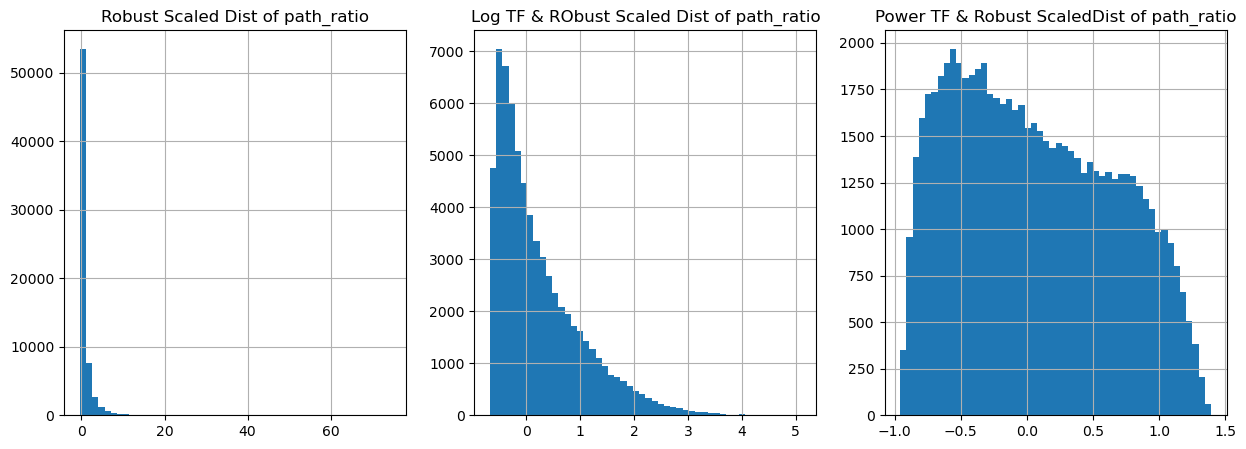

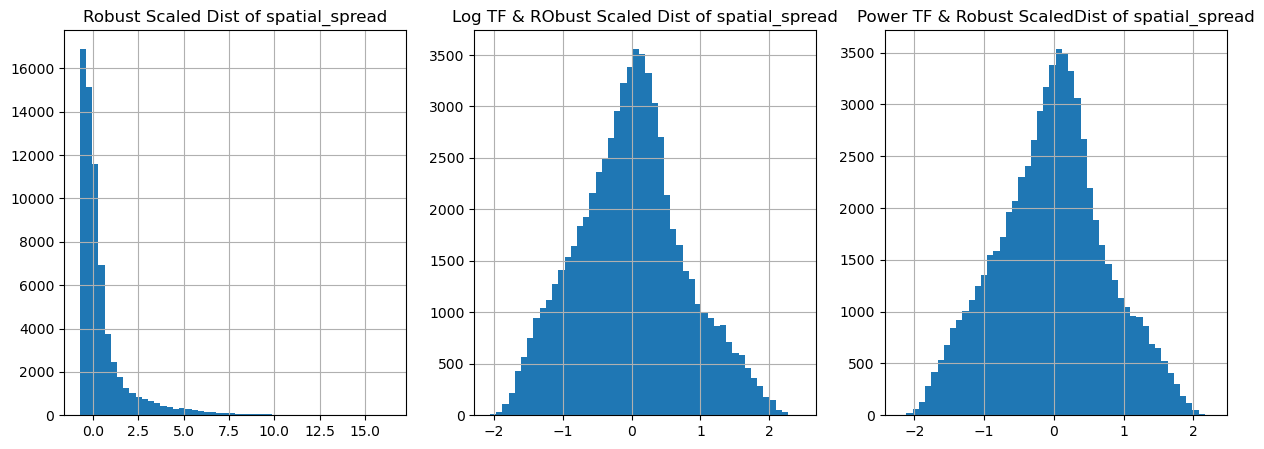

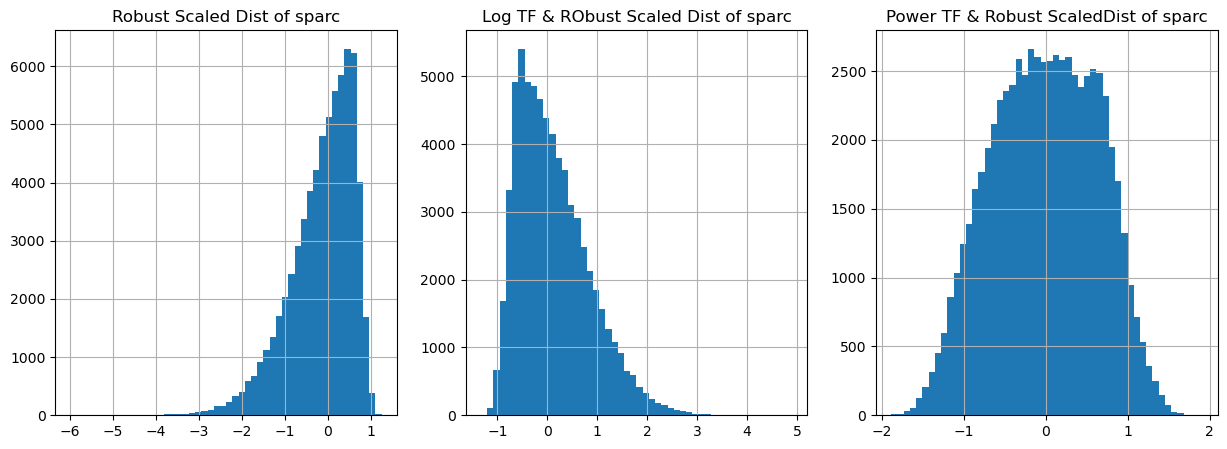

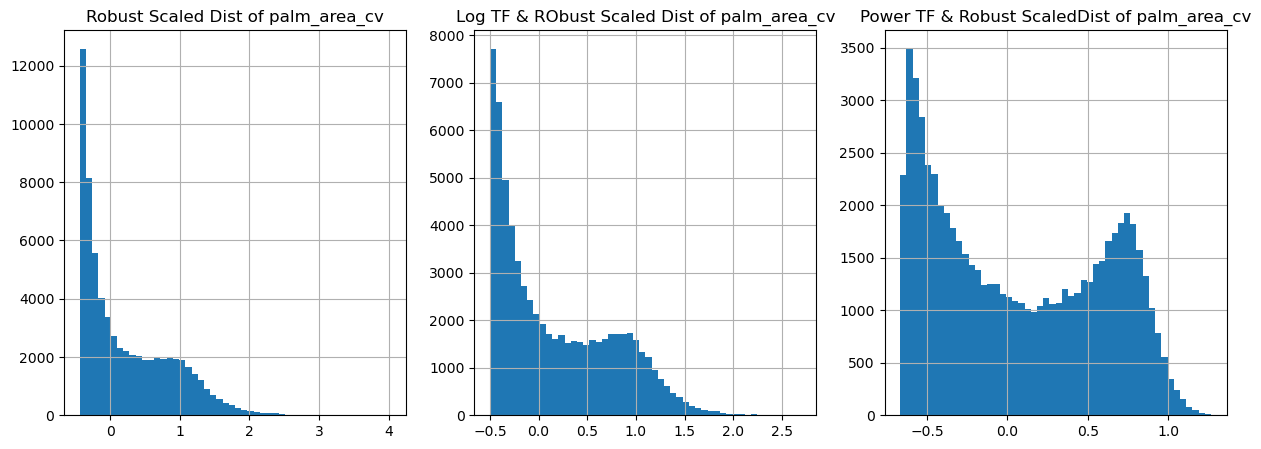

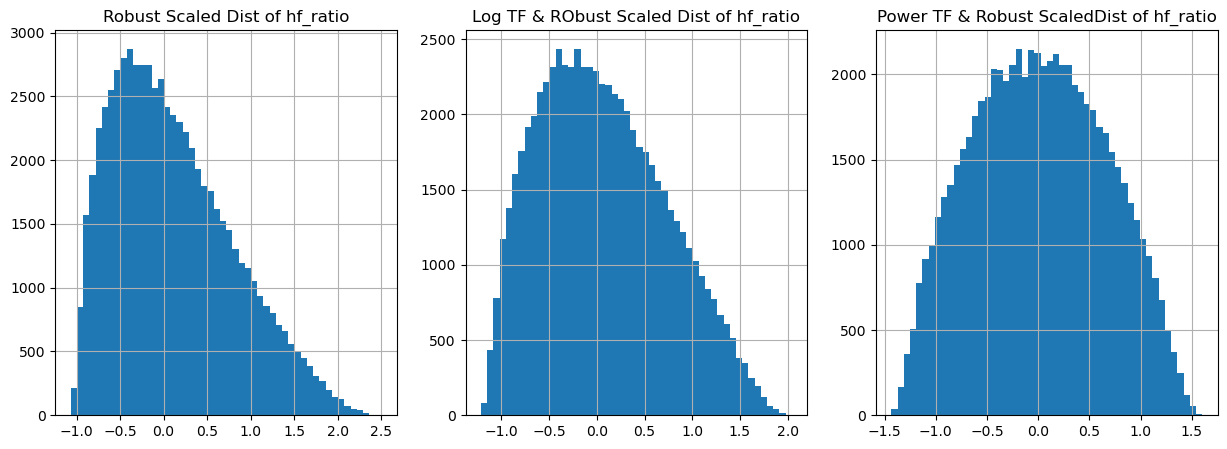

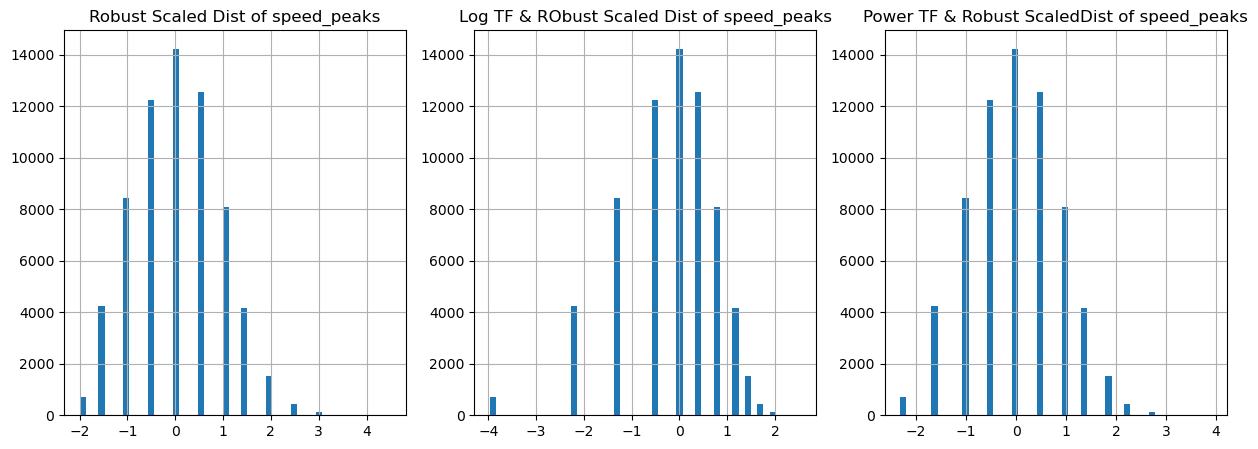

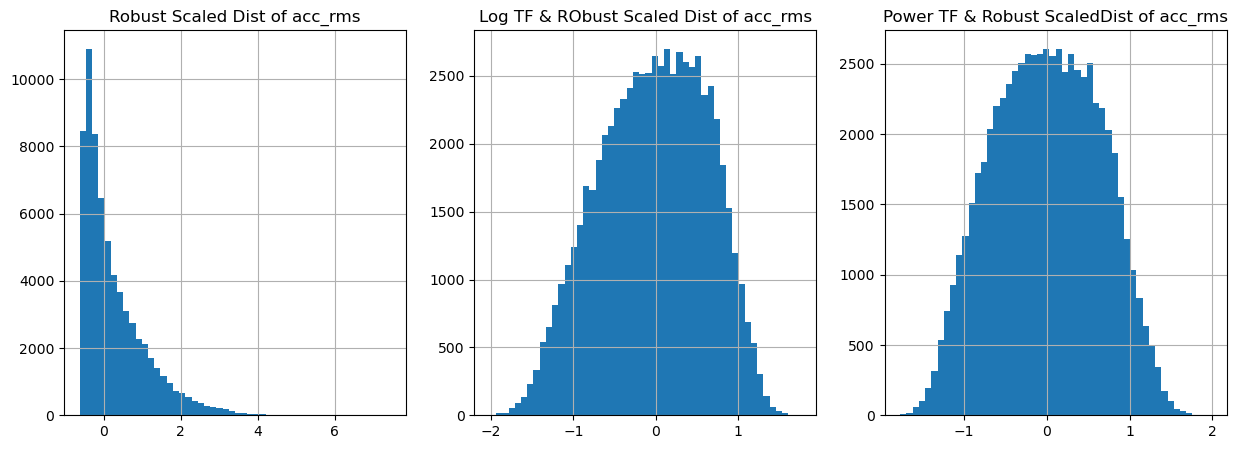

In [8]:
# Visualize distributions of key features before clustering

from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import PowerTransformer

scaler = RobustScaler()
p_tf = PowerTransformer(method='yeo-johnson', standardize=False)

for feat in ['path_ratio', 'spatial_spread', 'sparc', 'palm_area_cv', 'hf_ratio', 'speed_peaks', 'acc_rms']: #['bimanual_sync', 'bimanual_ratio', 'bimanual_dist_mean', 'bimanual_dist_std']:#

    X = df_window_features[feat]
    X_scaled = scaler.fit_transform(X.values.reshape(-1, 1))

    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1)
    plt.title(f"Robust Scaled Dist of {feat}")
    pd.Series(X_scaled.flatten()).hist(bins=50)

    plt.subplot(1, 3, 2)
    plt.title(f"Log TF & RObust Scaled Dist of {feat}")
    X_tf_scaled = scaler.fit_transform(df_window_features[feat].apply(lambda x: np.log1p(np.abs(x))).values.reshape(-1, 1))
    pd.Series(X_tf_scaled.flatten()).hist(bins=50)

    plt.subplot(1, 3, 3)
    plt.title(f"Power TF & Robust ScaledDist of {feat}")
    X_tf_scaled = scaler.fit_transform(p_tf.fit_transform(X.values.reshape(-1, 1)))
    pd.Series(X_tf_scaled.flatten()).hist(bins=50)

### **Start With Version Where the Clustering is Fitted on the Entire Data**
So there is some data leakage, but to get a general idea it is much faster

First cluster sensitivity analysis to evaluate how senstive the performance is to the predefined number of clusters.

The number of clusters resulting in the best performance is selected and used for interpretation of the kinematic bow features

In [9]:
def print_performance(summary, title):
    print(f"=== {title} ===")
    print(f"MAE: {summary['MAE']:.4f} ± {summary['MAE_STD']:.4f}")
    print(f"Spearman R: {summary['Spearman_R']:.4f} and R²: {summary['R2']:.4f}\n")

evaluator = LOSOEvaluator(EvaluationConfig(
    target_col="QRS_Overal",
    surgeon_col="Participant Number",
    video_col="video_id",
    device="cpu",
    seed=42,
))

In [10]:
n=3
# Define your settings
seeds = np.arange(n) * 42  # Add as many seeds as you want
cluster_range = range(8, 26, 1)

# Dictionary to store results for each seed
# Structure: {metric: {seed: [values_per_cluster]}}
results = {
    'MAE': {cluster: [] for cluster in cluster_range},
    'MAE_STD': {cluster: [] for cluster in cluster_range},
    'Spearman_R': {cluster: [] for cluster in cluster_range},
    'R2': {cluster: [] for cluster in cluster_range}
}

for n_cluster in cluster_range:    
    for seed in tqdm(seeds, desc=f"Evaluating seeds for {n_cluster} clusters"):
        #print("seed:", seed)
        # 1. Fit Vocabulary with current seed
        vocab = KinematicVocabulary(
            n_clusters=n_cluster, 
            random_state=seed, 
            model_type='kmeans', 
            n_init=10,
            feature_cols=['path_ratio', 'spatial_spread', 'palm_area_cv', 'sparc'],
            log_feats=['path_ratio', 'spatial_spread', 'sparc', 'palm_area_cv'],
        )

        vocab.fit(df_window)
        df_voc = vocab.transform(df_window)

        # 2. Prepare Data
        candidate_features = [col for col in df_voc.columns if col != 'video_id'] + ['Case_1', 'Case_2', 'Case_3']
        comb_df = pd.merge(df_pc1_features, df_voc, left_on='video_id', right_index=True)
        

        # 3. Evaluate
        res = evaluator.evaluate_tabular(
            df=comb_df,
            primary_features=pc1_features,
            extra_features=candidate_features,
            pca_components=[0],
            collect_weights=True,
            model=LassoCV(alphas=np.logspace(-1, 0.5, 30)),
            verbose=False
        )
        
        # 4. Store metrics
        summary = res['summary']
        results['MAE'][n_cluster].append(summary['MAE'])
        results['MAE_STD'][n_cluster].append(summary['MAE_STD'])
        results['Spearman_R'][n_cluster].append(summary['Spearman_R'])
        results['R2'][n_cluster].append(summary['R2'])
    
    summary = {metric: np.mean(results[metric][n_cluster]) for metric in results}
    print_performance(summary, f"{n_cluster} clusters - Average across seeds")


# --- Processing for Plotting ---
def get_stats(metric_dict):
    # Convert dict of lists to a 2D array: (seeds, n_clusters)
    arr = np.array([metric_dict[cluster] for cluster in cluster_range])
    return np.mean(arr, axis=0), np.std(arr, axis=0)

mae_mean, mae_std = get_stats(results['MAE'])
spearman_r_mean, spearman_r_std = get_stats(results['Spearman_R'])
r2_mean, r2_std = get_stats(results['R2'])

Evaluating seeds for 8 clusters: 100%|██████████| 3/3 [00:08<00:00,  2.68s/it]


=== 8 clusters - Average across seeds ===
MAE: 5.0692 ± 3.9433
Spearman R: 0.7213 and R²: 0.5239



Evaluating seeds for 9 clusters: 100%|██████████| 3/3 [00:08<00:00,  2.77s/it]


=== 9 clusters - Average across seeds ===
MAE: 4.8281 ± 3.9387
Spearman R: 0.7436 and R²: 0.5518



Evaluating seeds for 10 clusters: 100%|██████████| 3/3 [00:07<00:00,  2.64s/it]


...

=== 23 clusters - Average across seeds ===
MAE: 4.8137 ± 3.8419
Spearman R: 0.7490 and R²: 0.5621



Evaluating seeds for 24 clusters: 100%|██████████| 3/3 [00:12<00:00,  4.14s/it]


=== 24 clusters - Average across seeds ===
MAE: 4.8039 ± 3.8478
Spearman R: 0.7478 and R²: 0.5627



Evaluating seeds for 25 clusters: 100%|██████████| 3/3 [00:13<00:00,  4.61s/it]

=== 25 clusters - Average across seeds ===
MAE: 4.8383 ± 3.7917
Spearman R: 0.7495 and R²: 0.5638



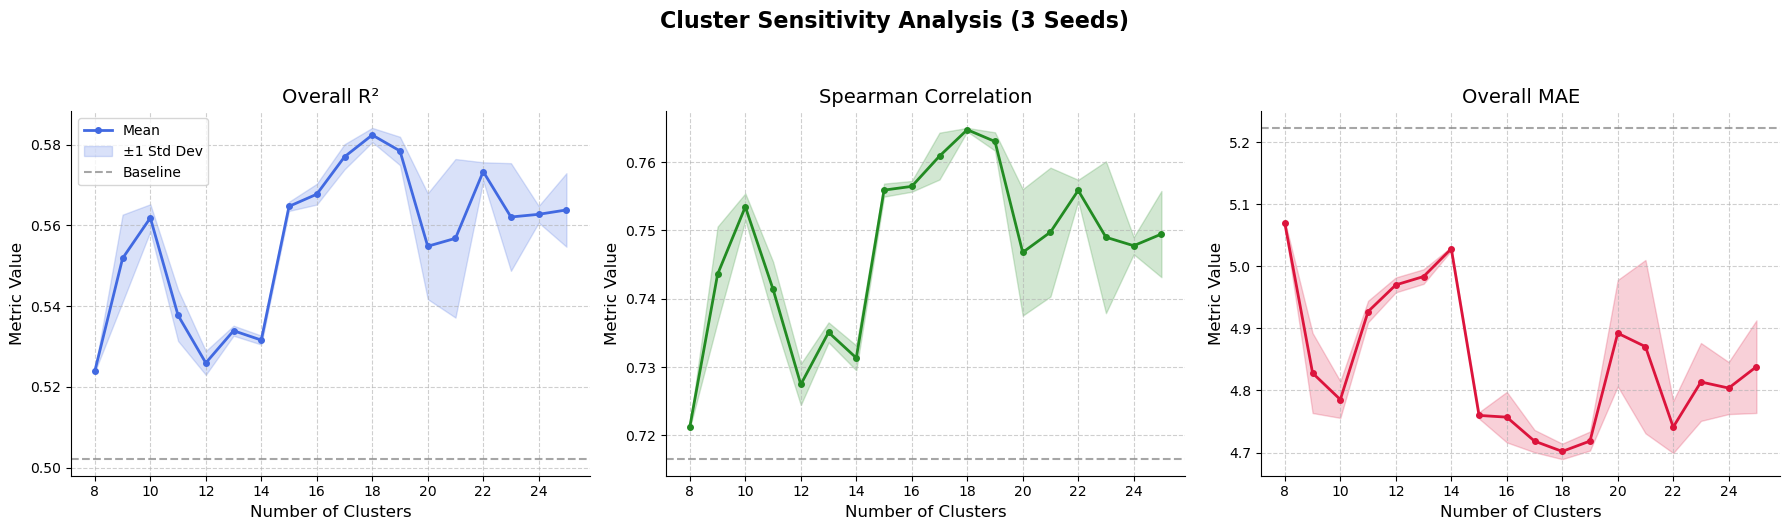

In [11]:
plot_sensitivity_results(cluster_range, results)

In [12]:
#df_window['spatial_spread'] = df_window['spatial_spread'].apply(lambda x: np.log1p(np.abs(x)))

kin_voc = KinematicVocabulary(n_clusters=18, random_state=42, model_type='kmeans', n_init=50,
                          feature_cols=['path_ratio', 'spatial_spread', 'palm_area_cv', 'sparc'],
                          log_feats=['path_ratio', 'spatial_spread', 'palm_area_cv', 'sparc'],
                          )

"""df_bimanual = df_window_features[df_window_features['bimanual_dist_mean'].notna()]
vocab = KinematicVocabulary(n_clusters=20, random_state=42, model_type='kmeans', n_init=5,
                            feature_cols=['total_path', 'path_ratio', 'spatial_spread', 'sparc', 'palm_area_cv', 'bimanual_dist_mean', 'bimanual_sync'],
                            log_feats=['total_path', 'path_ratio', 'spatial_spread', 'sparc'])
df_window = df_bimanual.copy()"""

kin_voc.fit(df_window)
df_voc = kin_voc.transform(df_window)
df_voc.head(5)


,BoW_feat_0,BoW_feat_1,BoW_feat_2,BoW_feat_3,BoW_feat_4,BoW_feat_5,BoW_feat_6,BoW_feat_7,BoW_feat_8,BoW_feat_9,BoW_feat_10,BoW_feat_11,BoW_feat_12,BoW_feat_13,BoW_feat_14,BoW_feat_15,BoW_feat_16,BoW_feat_17
"(2024-01-15_13-18-23, 1)",0.056786,0.061537,0.075706,0.062162,0.063759,0.029360,0.065477,0.029750,0.071392,0.054158,0.047292,0.054106,0.052803,0.059427,0.049269,0.077548,0.053335,0.036136
"(2024-01-15_13-37-36, 1)",0.054653,0.060398,0.074089,0.063313,0.061780,0.036852,0.057939,0.030946,0.070336,0.057699,0.049349,0.057738,0.051221,0.062587,0.044283,0.072403,0.051210,0.043203
"(2024-01-15_14-03-23, 1)",0.064741,0.056431,0.062614,0.052255,0.066271,0.033336,0.053708,0.045672,0.055185,0.066134,0.051700,0.047955,0.074304,0.056350,0.041719,0.061470,0.054208,0.055946
"(2024-01-15_14-32-45, 2)",0.054069,0.058318,0.082485,0.071447,0.064444,0.031201,0.057569,0.025582,0.079105,0.050455,0.051884,0.059863,0.047225,0.057107,0.039339,0.080486,0.058842,0.030579
"(2024-01-15_15-05-31, 2)",0.055686,0.063091,0.080458,0.073174,0.066583,0.028218,0.056563,0.025178,0.080554,0.049980,0.050935,0.059755,0.046384,0.056762,0.040540,0.078775,0.058959,0.028404


In [13]:
pearson_corrs, spearman_corrs = get_top_correlations(df_voc, df_scores['QRS_Overal'].to_list())

Top 15 features by Pearson correlation:
BoW_feat_13                    Pearson r = -0.5033, Spearman rho = -0.4785
BoW_feat_2                     Pearson r = -0.4989, Spearman rho = -0.4826
BoW_feat_12                    Pearson r = 0.4840, Spearman rho = 0.4755
BoW_feat_15                    Pearson r = -0.4775, Spearman rho = -0.4432
BoW_feat_17                    Pearson r = 0.4536, Spearman rho = 0.4645
BoW_feat_7                     Pearson r = 0.3961, Spearman rho = 0.4480
BoW_feat_8                     Pearson r = -0.3627, Spearman rho = -0.3613
BoW_feat_6                     Pearson r = -0.3573, Spearman rho = -0.2981
BoW_feat_9                     Pearson r = 0.3266, Spearman rho = 0.3071
BoW_feat_11                    Pearson r = -0.2692, Spearman rho = -0.2761
BoW_feat_3                     Pearson r = -0.2591, Spearman rho = -0.2458
BoW_feat_0                     Pearson r = 0.2567, Spearman rho = 0.2643
BoW_feat_1                     Pearson r = -0.2505, Spearman rho = -0.

In [14]:
# check cluster centroids for top positive and negative predictors
top_2_positive = np.argsort(pearson_corrs)[-9:]
top_2_negative = np.argsort(pearson_corrs)[:9]
if kin_voc.model_type == 'kmeans':
    centroids = kin_voc.model.cluster_centers_
else:
    centroids = kin_voc.model.means_
feature_names = kin_voc.feature_cols

print("--- Negative Predictors (Novice Moves) ---")
for idx in top_2_negative:
    print(f"Cluster {idx}, (corr: {round(pearson_corrs[idx], 3)}): {dict(zip(feature_names, np.round(centroids[idx], 2)))}")

print("\n--- Positive Predictors (Expert Moves) ---")
for idx in reversed(top_2_positive):
    print(f"Cluster {idx}, (corr: {round(pearson_corrs[idx], 3)}): {dict(zip(feature_names, np.round(centroids[idx], 2)))}")

--- Negative Predictors (Novice Moves) ---
Cluster 13, (corr: -0.503): {'path_ratio': np.float64(-0.19), 'spatial_spread': np.float64(0.98), 'palm_area_cv': np.float64(0.24), 'sparc': np.float64(0.59)}
Cluster 2, (corr: -0.499): {'path_ratio': np.float64(-0.2), 'spatial_spread': np.float64(0.08), 'palm_area_cv': np.float64(-0.38), 'sparc': np.float64(0.34)}
Cluster 15, (corr: -0.477): {'path_ratio': np.float64(-0.31), 'spatial_spread': np.float64(0.48), 'palm_area_cv': np.float64(-0.31), 'sparc': np.float64(-0.48)}
Cluster 8, (corr: -0.363): {'path_ratio': np.float64(-0.24), 'spatial_spread': np.float64(-0.32), 'palm_area_cv': np.float64(-0.46), 'sparc': np.float64(-0.47)}
Cluster 6, (corr: -0.357): {'path_ratio': np.float64(-0.39), 'spatial_spread': np.float64(1.35), 'palm_area_cv': np.float64(-0.16), 'sparc': np.float64(-0.48)}
Cluster 11, (corr: -0.269): {'path_ratio': np.float64(-0.05), 'spatial_spread': np.float64(-0.55), 'palm_area_cv': np.float64(-0.41), 'sparc': np.float64(1.08

In [15]:
top_positive = [f'BoW_feat_{idx}' for idx in top_2_positive]
top_negative = [f'BoW_feat_{idx}' for idx in top_2_negative]
top = top_positive + top_negative

df_voc[top].corr()

,BoW_feat_16,BoW_feat_4,BoW_feat_5,BoW_feat_10,BoW_feat_0,BoW_feat_9,BoW_feat_7,BoW_feat_17,BoW_feat_12,BoW_feat_13,BoW_feat_2,BoW_feat_15,BoW_feat_8,BoW_feat_6,BoW_feat_11,BoW_feat_3,BoW_feat_1,BoW_feat_14
BoW_feat_16,1.000000,-0.228479,0.419364,0.826063,-0.179516,-0.248591,-0.000803,-0.020014,-0.055622,-0.720276,0.068777,-0.173835,0.155820,-0.505792,0.480841,0.465500,-0.733597,-0.594581
BoW_feat_4,-0.228479,1.000000,-0.082592,-0.285117,0.347352,0.565799,0.039457,0.107615,0.358862,-0.055208,-0.307781,-0.280776,-0.210435,-0.405326,-0.315768,-0.216445,0.469350,-0.218013
BoW_feat_5,0.419364,-0.082592,1.000000,0.802919,-0.266429,0.336544,0.006450,0.416276,0.170380,-0.507285,-0.229735,-0.498805,-0.246511,-0.524439,0.369274,0.118207,-0.592288,-0.433963
BoW_feat_10,0.826063,-0.285117,0.802919,1.000000,-0.299439,-0.002199,0.031966,0.255748,0.065221,-0.740650,-0.113448,-0.399826,-0.066614,-0.533080,0.488350,0.338082,-0.813203,-0.508991
BoW_feat_0,-0.179516,0.347352,-0.266429,-0.299439,1.000000,0.603082,0.849224,0.602305,0.809094,-0.038350,-0.746534,-0.613520,-0.760039,-0.380008,-0.827788,-0.824981,0.167012,-0.063088
BoW_feat_9,-0.248591,0.565799,0.336544,-0.002199,0.603082,1.000000,0.540227,0.788172,0.836908,-0.150505,-0.775392,-0.793268,-0.801068,-0.584496,-0.571571,-0.711545,0.054291,-0.232760
BoW_feat_7,-0.000803,0.039457,0.006450,0.031966,0.849224,0.540227,1.000000,0.812534,0.875071,-0.326188,-0.854273,-0.759230,-0.832972,-0.436430,-0.749627,-0.795139,-0.183957,-0.076256
BoW_feat_17,-0.020014,0.107615,0.416276,0.255748,0.602305,0.788172,0.812534,1.000000,0.907270,-0.406304,-0.895993,-0.886739,-0.884434,-0.557733,-0.611327,-0.757779,-0.294183,-0.170287
BoW_feat_12,-0.055622,0.358862,0.170380,0.065221,0.809094,0.836908,0.875071,0.907270,1.000000,-0.382607,-0.933786,-0.882680,-0.900457,-0.601476,-0.747857,-0.816035,-0.138409,-0.200264
BoW_feat_13,-0.720276,-0.055208,-0.507285,-0.740650,-0.038350,-0.150505,-0.326188,-0.406304,-0.382607,1.000000,0.329339,0.494837,0.145544,0.714293,-0.151608,-0.144227,0.738124,0.619750


In [16]:
# combine the global and bow features
comb_df = pd.merge(df_pc1_features, df_voc, left_on='video_id', right_index=True)

pc1_features = [f for f in df_pc1_features.columns if '(R)' in f]
candidate_features = df_voc.columns.tolist()

# add case one-hotting to the combined df
df_case_onehot = pd.get_dummies(df_pc1_features['Case_Number'], prefix='Case').astype(int)

if not any('Case_1' in col for col in comb_df.columns):
    comb_df = pd.concat([comb_df, df_case_onehot], axis=1)

df_residuals_loso = loso_residual_analysis(comb_df, pc1_features, candidate_features, base_features=[], top_n=1, perform_shuffle=False)
df_residuals_loso

,Feature,Partial_R2_mean,Partial_R2_std,Partial_R2_min,Resid_Corr_mean,Selection_Stability
5,BoW_feat_13,0.147476,0.013183,0.120901,-0.366838,1.0
4,BoW_feat_12,0.126787,0.009878,0.102381,0.341055,0.0
10,BoW_feat_2,0.114336,0.010622,0.093614,-0.319231,0.0
14,BoW_feat_6,0.092437,0.012036,0.067577,-0.301358,0.0
7,BoW_feat_15,0.086878,0.010946,0.065578,-0.278193,0.0
9,BoW_feat_17,0.080713,0.008427,0.063883,0.270764,0.0
15,BoW_feat_7,0.073460,0.010107,0.058708,0.265261,0.0
12,BoW_feat_4,0.073045,0.010548,0.055843,0.271205,0.0
17,BoW_feat_9,0.053645,0.007027,0.042676,0.230041,0.0
3,BoW_feat_11,0.053589,0.008276,0.038448,-0.232032,0.0


In [17]:
if not [any('Case_1' in col for col in comb_df.columns)]:
    comb_df = pd.concat([comb_df, df_case_onehot], axis=1)
if not any('Case_1' in feature for feature in candidate_features):
    candidate_features += list(df_case_onehot.columns)

evaluator = LOSOEvaluator(EvaluationConfig(
    target_col="QRS_Overal",
    surgeon_col="Participant Number",
    video_col="video_id",
    device="cpu",
    seed=42,
))

results = evaluator.evaluate_tabular(
    df=comb_df,
    primary_features=pc1_features,
    extra_features=candidate_features,
    pca_components=[0],
    collect_weights=True,
    model=LassoCV(alphas=np.logspace(-1, 0.5, 30)),
    verbose=False
)

print_performance(results['summary'], "LassoCV PC1 + casetypes + spatial spread median")
print(results['weights'])

=== LassoCV PC1 + casetypes + spatial spread median ===
MAE: 4.6943 ± 3.7496
Spearman R: 0.7646 and R²: 0.5834

        Feature  Average_Weight  Std_Weight
0          bias       49.938586    0.308361
1           PC1       -4.996088    0.173930
2    BoW_feat_0        0.000000    0.000000
3    BoW_feat_1       -0.015084    0.079816
4    BoW_feat_2       -0.057663    0.136197
5    BoW_feat_3        0.000000    0.000000
6    BoW_feat_4        0.861051    0.155654
7    BoW_feat_5       -0.000079    0.000420
8    BoW_feat_6        0.000000    0.000000
9    BoW_feat_7        0.000000    0.000000
10   BoW_feat_8        0.000000    0.000000
11   BoW_feat_9        0.000000    0.000000
12  BoW_feat_10        0.000000    0.000000
13  BoW_feat_11       -1.474073    0.177025
14  BoW_feat_12        0.000000    0.000000
15  BoW_feat_13       -2.700531    0.141888
16  BoW_feat_14        0.000000    0.000000
17  BoW_feat_15        0.000000    0.000000
18  BoW_feat_16        0.000000    0.000000
19  BoW_

In [24]:
# ElastiNetCV for comparison
results = evaluator.evaluate_tabular(
    df=comb_df,
    primary_features=pc1_features,
    extra_features=candidate_features,
    pca_components=[0],
    collect_weights=True,
    model=ElasticNetCV(l1_ratio=[0.2, 0.5, 0.7, 0.9, 0.95, 0.99], alphas=np.logspace(-1, 0.5, 30)),
    verbose=False
)

print_performance(results['summary'], "ElasticNetCV PC1 + casetypes + spatial spread median")
print(results['weights'])

=== ElasticNetCV PC1 + casetypes + spatial spread median ===
MAE: 4.7003 ± 3.7744
Spearman R: 0.7638 and R²: 0.5806

        Feature  Average_Weight  Std_Weight
0          bias       49.938586    0.308361
1           PC1       -4.905021    0.232342
2    BoW_feat_0        0.000000    0.000000
3    BoW_feat_1        0.000000    0.000000
4    BoW_feat_2        0.000000    0.000000
5    BoW_feat_3       -0.022544    0.089069
6    BoW_feat_4       -2.645395    0.177853
7    BoW_feat_5       -0.197507    0.262789
8    BoW_feat_6        0.000000    0.000000
9    BoW_feat_7        0.000000    0.000000
10   BoW_feat_8       -1.379527    0.261918
11   BoW_feat_9        0.000000    0.000000
12  BoW_feat_10        0.000000    0.000000
13  BoW_feat_11        0.000000    0.000000
14  BoW_feat_12        0.000000    0.000000
15  BoW_feat_13        0.000000    0.000000
16  BoW_feat_14        0.895867    0.152685
17  BoW_feat_15        0.000000    0.000000
18  BoW_feat_16        0.000000    0.000000
19 

In [ ]:
# MLP with the thee consistently extracted bow features

from thesis_package.models.mlp_regressor import PyTorchMLPEnsemble

mlp = PyTorchMLPEnsemble(input_dim=4,
                           hidden_dim=16,
                           n_hidden=1,
                           n_models=5,
                           dropout=0.2,
                           batch_size=16)

mlp_results = evaluator.evaluate_tabular(
    df=comb_df,
    primary_features=pc1_features,
    extra_features=['BoW_feat_4', 'BoW_feat_8', 'BoW_feat_14'],
    model=mlp,
    pca_components=[0],
    selector=None,
    scale_target=True,
    verbose=False,
    print_fold_metrics=True
)

print_performance(mlp_results['summary'], "MLP with Right PC1 + Case Type Dummies")

Fold 1 - Test Group [np.int64(1)]: Test MAE: 3.1007, Train MAE: 3.9637, N primary: 5
Fold 2 - Test Group [np.int64(2)]: Test MAE: 2.9247, Train MAE: 4.0007, N primary: 5
Fold 3 - Test Group [np.int64(3)]: Test MAE: 9.2775, Train MAE: 3.8053, N primary: 5
Fold 4 - Test Group [np.int64(4)]: Test MAE: 2.6572, Train MAE: 3.9635, N primary: 5
Fold 5 - Test Group [np.int64(5)]: Test MAE: 5.9514, Train MAE: 3.8745, N primary: 5
Fold 6 - Test Group [np.int64(6)]: Test MAE: 2.5915, Train MAE: 3.9907, N primary: 5
Fold 7 - Test Group [np.int64(7)]: Test MAE: 9.8311, Train MAE: 3.7187, N primary: 5
Fold 8 - Test Group [np.int64(9)]: Test MAE: 1.4763, Train MAE: 3.9869, N primary: 5
Fold 9 - Test Group [np.int64(10)]: Test MAE: 3.6319, Train MAE: 3.9403, N primary: 5
Fold 10 - Test Group [np.int64(11)]: Test MAE: 0.9520, Train MAE: 4.0360, N primary: 5
Fold 11 - Test Group [np.int64(12)]: Test MAE: 4.1913, Train MAE: 3.9316, N primary: 5
Fold 12 - Test Group [np.int64(13)]: Test MAE: 3.2078, Train

In [38]:
# MLP with the thee consistently extracted bow features

from thesis_package.models.mlp_regressor import PyTorchMLPEnsemble

mlp = PyTorchMLPEnsemble(input_dim=1 + len(candidate_features),
                           hidden_dim=16,
                           n_hidden=1,
                           n_models=5,
                           dropout=0.2,
                           batch_size=16)

mlp_results = evaluator.evaluate_tabular(
    df=comb_df,
    primary_features=pc1_features,
    extra_features=candidate_features,
    model=mlp,
    pca_components=[0],
    selector=None,
    scale_target=True,
    verbose=False,
    print_fold_metrics=True
)

print_performance(mlp_results['summary'], "MLP with Right PC1 + Case Type Dummies")

Fold 1 - Test Group [np.int64(1)]: Test MAE: 2.9445, Train MAE: 3.5053, N primary: 5
Fold 2 - Test Group [np.int64(2)]: Test MAE: 2.9968, Train MAE: 3.5984, N primary: 5
Fold 3 - Test Group [np.int64(3)]: Test MAE: 11.1314, Train MAE: 3.3609, N primary: 5
Fold 4 - Test Group [np.int64(4)]: Test MAE: 2.9157, Train MAE: 3.4920, N primary: 5
Fold 5 - Test Group [np.int64(5)]: Test MAE: 5.5159, Train MAE: 3.3737, N primary: 5
Fold 6 - Test Group [np.int64(6)]: Test MAE: 4.4648, Train MAE: 3.4126, N primary: 5
Fold 7 - Test Group [np.int64(7)]: Test MAE: 11.8312, Train MAE: 3.2328, N primary: 5
Fold 8 - Test Group [np.int64(9)]: Test MAE: 2.4424, Train MAE: 3.5903, N primary: 5
Fold 9 - Test Group [np.int64(10)]: Test MAE: 3.3745, Train MAE: 3.5672, N primary: 5
Fold 10 - Test Group [np.int64(11)]: Test MAE: 1.2312, Train MAE: 3.6699, N primary: 5
Fold 11 - Test Group [np.int64(12)]: Test MAE: 4.0908, Train MAE: 3.4187, N primary: 5
Fold 12 - Test Group [np.int64(13)]: Test MAE: 3.5484, Tra

## Bow Features Alone
- How well can BoW features alone explain skill scores?

- Does the best number of clusters match that of the hybrid BoW + pc1 model?

In [39]:
n=10
# Define your settings
seeds = np.arange(n) * 42  # Add as many seeds as you want
cluster_range = range(8, 26, 1)

# Dictionary to store results for each seed
# Structure: {metric: {seed: [values_per_cluster]}}
results = {
    'MAE': {cluster: [] for cluster in cluster_range},
    'MAE_STD': {cluster: [] for cluster in cluster_range},
    'Spearman_R': {cluster: [] for cluster in cluster_range},
    'R2': {cluster: [] for cluster in cluster_range}
}

for n_cluster in cluster_range:    
    for seed in tqdm(seeds, desc=f"Evaluating seeds for {n_cluster} clusters"):
        #print("seed:", seed)
        # 1. Fit Vocabulary with current seed
        vocab = KinematicVocabulary(
            n_clusters=n_cluster, 
            random_state=seed, 
            model_type='kmeans', 
            n_init=10,
            feature_cols=['path_ratio', 'spatial_spread', 'palm_area_cv', 'sparc'],
            log_feats=['path_ratio', 'spatial_spread', 'sparc', 'palm_area_cv'],
        )

        vocab.fit(df_window)
        df_voc = vocab.transform(df_window)

        # 2. Prepare Data
        candidate_features = [col for col in df_voc.columns if col != 'video_id']
        comb_df = pd.merge(df_pc1_features, df_voc, left_on='video_id', right_index=True)

        # 3. Evaluate
        res = evaluator.evaluate_tabular(
            df=comb_df,
            primary_features=[],
            extra_features=candidate_features,
            collect_weights=True,
            model=LassoCV(alphas=np.logspace(-1, 0.5, 30)),
            verbose=False
        )
        
        # 4. Store metrics
        summary = res['summary']
        results['MAE'][n_cluster].append(summary['MAE'])
        results['MAE_STD'][n_cluster].append(summary['MAE_STD'])
        results['Spearman_R'][n_cluster].append(summary['Spearman_R'])
        results['R2'][n_cluster].append(summary['R2'])
    
    summary = {metric: np.mean(results[metric][n_cluster]) for metric in results}
    print_performance(summary, f"{n_cluster} clusters - Average across seeds")


# --- Processing for Plotting ---
def get_stats(metric_dict):
    # Convert dict of lists to a 2D array: (seeds, n_clusters)
    arr = np.array([metric_dict[cluster] for cluster in cluster_range])
    return np.mean(arr, axis=0), np.std(arr, axis=0)

mae_mean, mae_std = get_stats(results['MAE'])
spearman_r_mean, spearman_r_std = get_stats(results['Spearman_R'])
r2_mean, r2_std = get_stats(results['R2'])

Evaluating seeds for 8 clusters: 100%|██████████| 10/10 [00:24<00:00,  2.43s/it]


=== 8 clusters - Average across seeds ===
MAE: 7.2928 ± 4.6334
Spearman R: 0.3442 and R²: 0.1379



Evaluating seeds for 9 clusters: 100%|██████████| 10/10 [00:20<00:00,  2.09s/it]


=== 9 clusters - Average across seeds ===
MAE: 6.4987 ± 4.3972
Spearman R: 0.5192 and R²: 0.2888



Evaluating seeds for 10 clusters: 100%|██████████| 10/10 [00:21<00:00,  2.12s/it]


...

=== 23 clusters - Average across seeds ===
MAE: 6.7868 ± 4.4653
Spearman R: 0.4395 and R²: 0.2380



Evaluating seeds for 24 clusters:   0%|          | 0/10 [00:00<?, ?it/s]/Users/finnweikert/opt/anaconda3/envs/env-ml/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.251e-01, tolerance: 6.559e-01
  model = cd_fast.enet_coordinate_descent_gram(
Evaluating seeds for 24 clusters:  10%|█         | 1/10 [00:03<00:32,  3.66s/it]/Users/finnweikert/opt/anaconda3/envs/env-ml/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.299e-01, tolerance: 5.798e-01
  model = cd_fast.enet_coordinate_descent_gram(
Evaluating seeds for 24 clusters:  80%|████████  | 8/10 [00:29<00:07,  3

=== 24 clusters - Average across seeds ===
MAE: 6.8063 ± 4.4732
Spearman R: 0.4357 and R²: 0.2343



Evaluating seeds for 25 clusters:  20%|██        | 2/10 [00:07<00:30,  3.86s/it]/Users/finnweikert/opt/anaconda3/envs/env-ml/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.038e-01, tolerance: 6.518e-01
  model = cd_fast.enet_coordinate_descent_gram(
Evaluating seeds for 25 clusters: 100%|██████████| 10/10 [00:38<00:00,  3.86s/it]

=== 25 clusters - Average across seeds ===
MAE: 6.7126 ± 4.4177
Spearman R: 0.4580 and R²: 0.2546



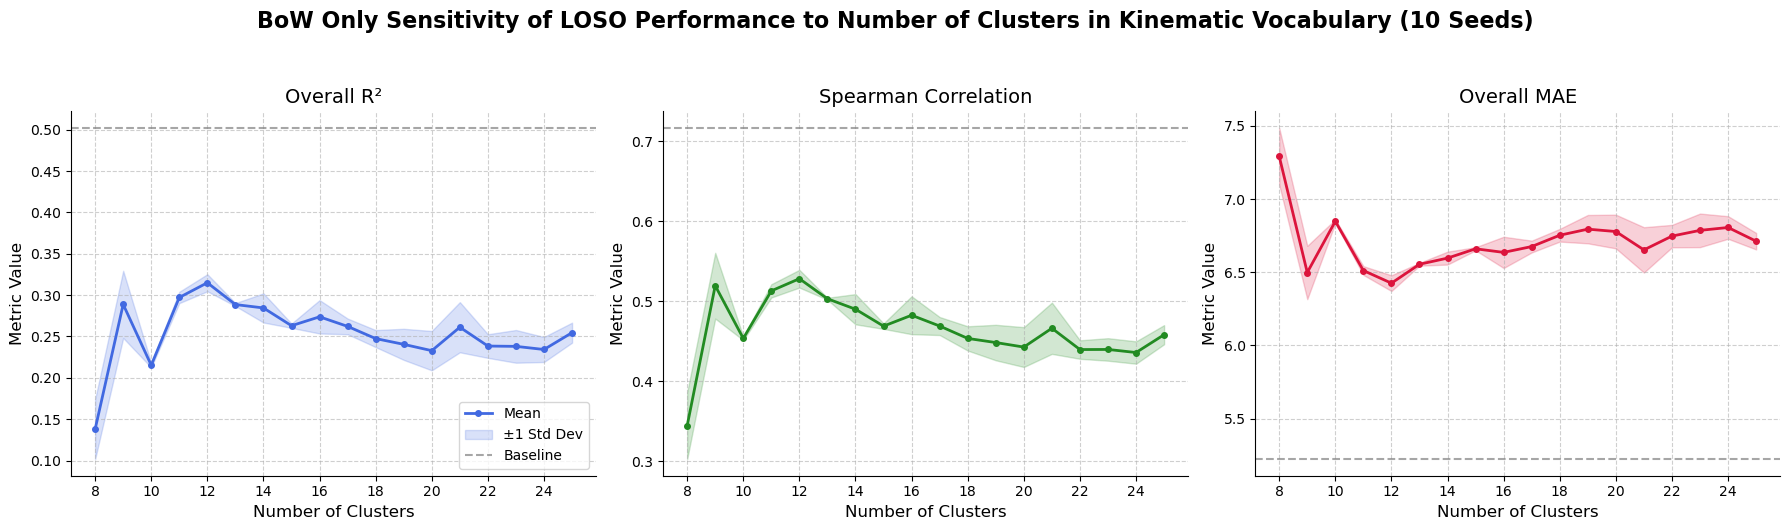

In [42]:
plot_sensitivity_results(cluster_range, results, title="BoW Only Sensitivity of LOSO Performance to Number of Clusters in Kinematic Vocabulary")

In [25]:
vocab = KinematicVocabulary(
    n_clusters=12, 
    random_state=42, 
    model_type='kmeans', 
    n_init=20,
    feature_cols=['path_ratio', 'spatial_spread', 'palm_area_cv', 'sparc'],
    log_feats=['path_ratio', 'spatial_spread', 'sparc', 'palm_area_cv'],
)

vocab.fit(df_window)
df_voc = vocab.transform(df_window)

candidate_features = [col for col in df_voc.columns if col != 'video_id']
comb_df = pd.merge(df_pc1_features, df_voc, left_on='video_id', right_index=True)

if not [any('Case_1' in col for col in comb_df.columns)]:
    comb_df = pd.concat([comb_df, df_case_onehot], axis=1)
    candidate_features += list(df_case_onehot.columns)

evaluator = LOSOEvaluator(EvaluationConfig(
    target_col="QRS_Overal",
    surgeon_col="Participant Number",
    video_col="video_id",
    device="cpu",
    seed=42,
))

# 3. Evaluate
res = evaluator.evaluate_tabular(
    df=comb_df,
    primary_features=[],
    extra_features=candidate_features,
    collect_weights=True,
    model=LassoCV(alphas=np.logspace(-1, 0.5, 30)),
    verbose=False
)

print_performance(res['summary'], "LassoCV PC1 + casetypes + spatial spread median")
print(res['weights'])

=== LassoCV PC1 + casetypes + spatial spread median ===
MAE: 6.3484 ± 4.2177
Spearman R: 0.5427 and R²: 0.3295

        Feature  Average_Weight  Std_Weight
0          bias       49.938586    0.308361
1    BoW_feat_0        0.000000    0.000000
2    BoW_feat_1       -4.979538    0.176150
3    BoW_feat_2        0.000000    0.000000
4    BoW_feat_3        0.000000    0.000000
5    BoW_feat_4        0.000000    0.000000
6    BoW_feat_5        0.000000    0.000000
7    BoW_feat_6        0.000000    0.000000
8    BoW_feat_7        0.000000    0.000000
9    BoW_feat_8        0.000000    0.000000
10   BoW_feat_9        0.000000    0.000000
11  BoW_feat_10        0.000000    0.000000
12  BoW_feat_11        0.000000    0.000000


One BoW features dominates!
Lets look at its centroid.

In [ ]:
centroid = vocab.model.cluster_centers_[1]
feature_names = vocab.feature_cols
print(f"Cluster 1 Centroid: {dict(zip(feature_names, np.round(centroid, 2)))}")

Cluster 1 Centroid: {'path_ratio': np.float64(-0.19), 'spatial_spread': np.float64(0.59), 'palm_area_cv': np.float64(-0.11), 'sparc': np.float64(0.57)}


# Now Kmeans Fitted in LOSO (leakage-free)

In [54]:
n=3
# Define your settings
seeds = np.arange(n) * 42  # Add as many seeds as you want
cluster_range = range(8, 26, 1)

# Dictionary to store results for each seed
# Structure: {metric: {seed: [values_per_cluster]}}
results = {
    'MAE': {cluster: [] for cluster in cluster_range},
    'MAE_STD': {cluster: [] for cluster in cluster_range},
    'Spearman_R': {cluster: [] for cluster in cluster_range},
    'R2': {cluster: [] for cluster in cluster_range}
}

for n_cluster in cluster_range:    
    for seed in tqdm(seeds, desc=f"Evaluating seeds for {n_cluster} clusters"):
        #print("seed:", seed)
        # 1. Fit Vocabulary with current seed
        vocab = KinematicVocabulary(
            n_clusters=n_cluster, 
            random_state=seed, 
            model_type='kmeans', 
            n_init=10,
            feature_cols=['path_ratio', 'spatial_spread', 'palm_area_cv', 'sparc'],
            log_feats=['path_ratio', 'spatial_spread', 'sparc', 'palm_area_cv'],
        )

        # 3. Evaluate
        res = evaluator.evaluate_vocabulary(
            df_pc1_features,
            df_window,
            vocab,
            model=LassoCV(alphas=np.logspace(-1, 0.5, 20)),
            primary_features=pc1_features,
            bow_features=[col for col in df_voc.columns if col != 'video_id'],
            extra_features=['Case_1', 'Case_2', 'Case_3'],
            leakage_free=True,
            use_baseline=True,
        )
        
        # 4. Store metrics
        summary = res['summary']
        results['MAE'][n_cluster].append(summary['MAE'])
        results['MAE_STD'][n_cluster].append(summary['MAE_STD'])
        results['Spearman_R'][n_cluster].append(summary['Spearman_R'])
        results['R2'][n_cluster].append(summary['R2'])
    
    summary = {metric: np.mean(results[metric][n_cluster]) for metric in results}
    print_performance(summary, f"{n_cluster} clusters - Average across seeds")


# --- Processing for Plotting ---
def get_stats(metric_dict):
    # Convert dict of lists to a 2D array: (seeds, n_clusters)
    arr = np.array([metric_dict[cluster] for cluster in cluster_range])
    return np.mean(arr, axis=0), np.std(arr, axis=0)

mae_mean, mae_std = get_stats(results['MAE'])
spearman_r_mean, spearman_r_std = get_stats(results['Spearman_R'])
r2_mean, r2_std = get_stats(results['R2'])

Evaluating seeds for 8 clusters: 100%|██████████| 3/3 [01:41<00:00, 33.83s/it]


=== 8 clusters - Average across seeds ===
MAE: 5.0919 ± 3.9249
Spearman R: 0.7226 and R²: 0.5229



Evaluating seeds for 9 clusters: 100%|██████████| 3/3 [01:57<00:00, 39.14s/it]


=== 9 clusters - Average across seeds ===
MAE: 4.7954 ± 3.8533
Spearman R: 0.7512 and R²: 0.5632



Evaluating seeds for 10 clusters:  67%|██████▋   | 2/3 [02:17<01:08, 68.75s/it]


KeyboardInterrupt: 

In [ ]:
plot_sensitivity_results(cluster_range, results)

**Thesis Result:** With k=18 and many inits

In [18]:
# with K = 18 !THESIS RESULT!
seed = 42
print('seed:', seed)
vocab = KinematicVocabulary(n_clusters=18, random_state=seed, model_type='kmeans', n_init=20,
                            feature_cols=['path_ratio', 'spatial_spread', 'palm_area_cv', 'sparc'],
                            log_feats=['path_ratio', 'spatial_spread', 'palm_area_cv', 'sparc'],
                            power_feats=None)


res = evaluator.evaluate_vocabulary(
    df_pc1_features,
    df_window,
    vocab,
    model=LassoCV(alphas=np.logspace(-1, 0.5, 30)),
    primary_features=pc1_features,
    bow_features=['SurgeMe_' + str(i) for i in range(18)],
    extra_features=['Case_1', 'Case_2', 'Case_3'],
    leakage_free=True,
    use_baseline=True,
)

summary = res['summary']
print_performance(summary, f"18 Clusters - Results")

all_fold_centroids = res["fold_centroids"]

seed: 42


Vocabulary LOSO: 100%|██████████| 28/28 [01:30<00:00,  3.23s/it]

=== 18 Clusters - Results ===
MAE: 4.6950 ± 3.7459
Spearman R: 0.7642 and R²: 0.5836



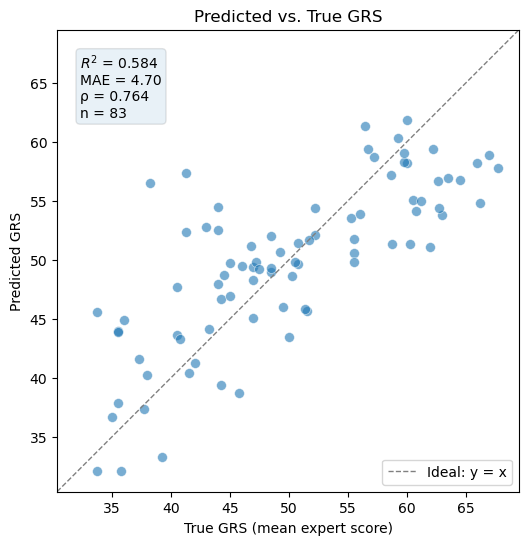

In [19]:
_, _ = plot_predicted_vs_true(res['predictions'], 
                       show_group_labels=False, 
                       add_fit_line=False)

# Align Fold Centroids To A Global Template

In [ ]:
df_combined = pd.merge(df_pc1_features, df_voc, left_on='video_id', right_index=True)


if not [any('Case_1' in col for col in comb_df.columns)]:
    comb_df = pd.concat([comb_df, df_case_onehot], axis=1)
if not any('Case_1' in feature for feature in candidate_features):
    candidate_features += list(df_case_onehot.columns)

evaluator = LOSOEvaluator(EvaluationConfig(
    target_col="QRS_Overal",
    surgeon_col="Participant Number",
    video_col="video_id",
    device="cpu",
    seed=42,
))

results = evaluator.evaluate_tabular(
    df=comb_df,
    primary_features=pc1_features,
    extra_features=candidate_features,
    pca_components=[0],
    collect_weights=True,
    model=LassoCV(alphas=np.logspace(-1, 0.5, 30)),
    verbose=False
)

print_performance(results['summary'], "LassoCV PC1 + casetypes + spatial spread median")
print(results['weights'])

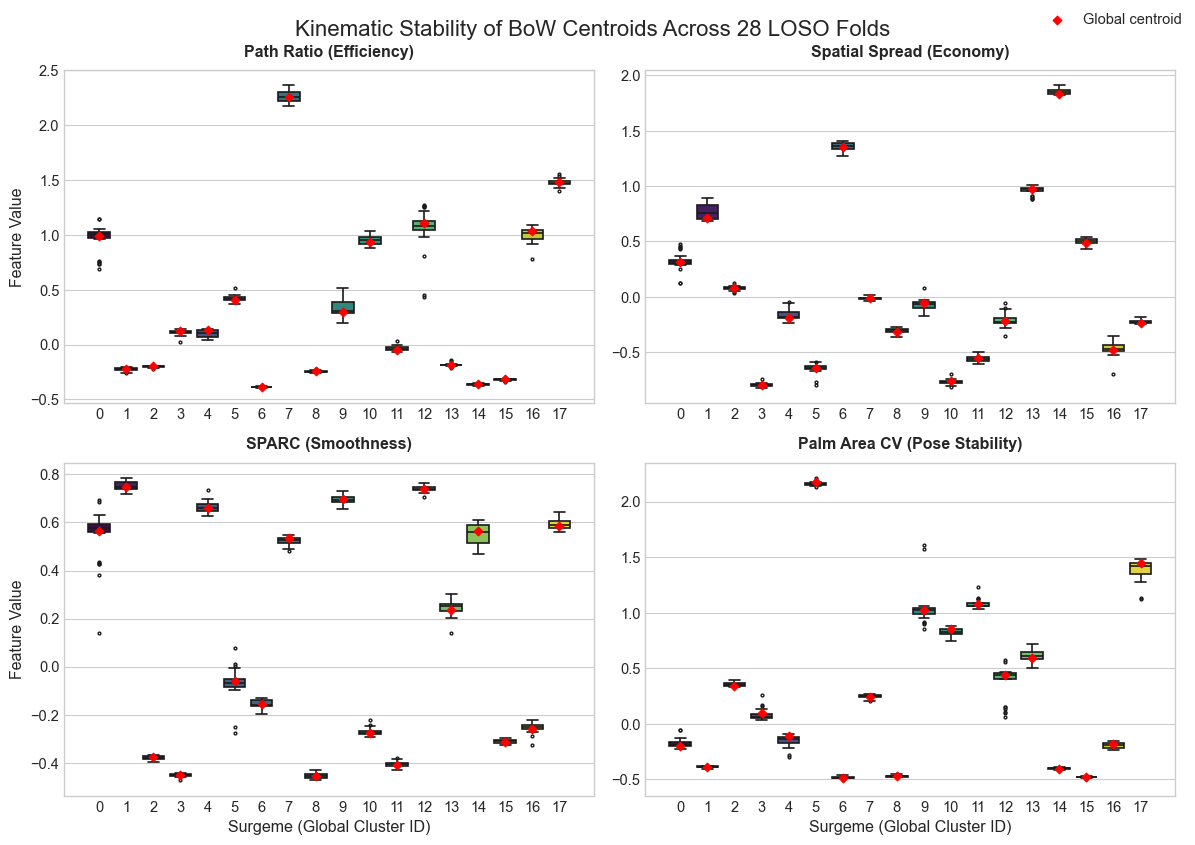

In [54]:
global_centers = kin_voc.model.cluster_centers_
df_stability = align_fold_centroids(global_centers, all_fold_centroids)

# Let's look at 'sparc' stability across the 18 clusters
plot_surgeme_stability(df_stability, global_centers)

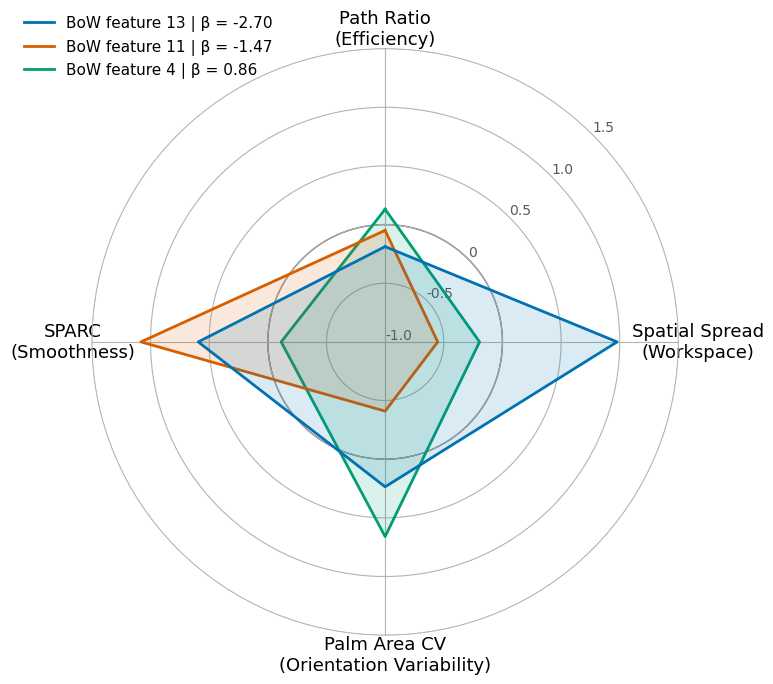

In [57]:
feat_names = [
     'Path Ratio\n(Efficiency)', 
     'Spatial Spread\n(Workspace)', 
     'Palm Area CV\n(Orientation Variability)', 
     'SPARC\n(Smoothness)'
 ]

clusters_to_show = [
     {'id': 13, 'label': 'Exploratory Motion', 'coef': -2.70},
     {'id': 11, 'label': 'Smooth Manipulation', 'coef': -1.47},
     {'id': 4,  'label': 'Stabilization', 'coef': 0.86}
]

#global_centers = kin_voc.model.cluster_centers_

plot_surgeme_radar(global_centers, feat_names, clusters_to_show)

### **With Velocity Correlation**

In [ ]:
df_pc1_features.head()

In [79]:
n=3
# Define your settings
seeds = np.arange(n) * 42  # Add as many seeds as you want
cluster_range = range(8, 26, 1)

# Dictionary to store results for each seed
# Structure: {metric: {seed: [values_per_cluster]}}
results = {
    'MAE': {cluster: [] for cluster in cluster_range},
    'MAE_STD': {cluster: [] for cluster in cluster_range},
    'Spearman_R': {cluster: [] for cluster in cluster_range},
    'R2': {cluster: [] for cluster in cluster_range}
}

for n_cluster in cluster_range:    
    for seed in tqdm(seeds, desc=f"Evaluating seeds for {n_cluster} clusters"):
        #print("seed:", seed)
        # 1. Fit Vocabulary with current seed
        vocab = KinematicVocabulary(
            n_clusters=n_cluster, 
            random_state=seed, 
            model_type='kmeans', 
            n_init=10,
            feature_cols=['path_ratio', 'spatial_spread', 'palm_area_cv', 'sparc'],
            log_feats=['path_ratio', 'spatial_spread', 'sparc', 'palm_area_cv'],
        )

        vocab.fit(df_window)
        df_voc = vocab.transform(df_window)

        # 2. Prepare Data
        candidate_features = [col for col in df_voc.columns if col != 'video_id'] + ['Case_1', 'Case_2', 'Case_3'] + ['Velocity corr.']
        comb_df = pd.merge(df_pc1_features, df_voc, left_on='video_id', right_index=True)
        

        # 3. Evaluate
        res = evaluator.evaluate_tabular(
            df=comb_df,
            primary_features=pc1_features,
            extra_features=candidate_features,
            pca_components=[0],
            collect_weights=True,
            model=LassoCV(alphas=np.logspace(-1, 0.5, 30)),
            verbose=False
        )
        
        # 4. Store metrics
        summary = res['summary']
        results['MAE'][n_cluster].append(summary['MAE'])
        results['MAE_STD'][n_cluster].append(summary['MAE_STD'])
        results['Spearman_R'][n_cluster].append(summary['Spearman_R'])
        results['R2'][n_cluster].append(summary['R2'])
    
    summary = {metric: np.mean(results[metric][n_cluster]) for metric in results}
    print_performance(summary, f"{n_cluster} clusters - Average across seeds")


# --- Processing for Plotting ---
def get_stats(metric_dict):
    # Convert dict of lists to a 2D array: (seeds, n_clusters)
    arr = np.array([metric_dict[cluster] for cluster in cluster_range])
    return np.mean(arr, axis=0), np.std(arr, axis=0)

mae_mean, mae_std = get_stats(results['MAE'])
spearman_r_mean, spearman_r_std = get_stats(results['Spearman_R'])
r2_mean, r2_std = get_stats(results['R2'])

Evaluating seeds for 8 clusters: 100%|██████████| 3/3 [00:11<00:00,  3.90s/it]


=== 8 clusters - Average across seeds ===
MAE: 4.9168 ± 3.6383
Spearman R: 0.7602 and R²: 0.5682



Evaluating seeds for 9 clusters: 100%|██████████| 3/3 [00:09<00:00,  3.07s/it]


=== 9 clusters - Average across seeds ===
MAE: 4.7647 ± 3.6741
Spearman R: 0.7817 and R²: 0.5820



Evaluating seeds for 10 clusters: 100%|██████████| 3/3 [00:09<00:00,  3.17s/it]


...

=== 23 clusters - Average across seeds ===
MAE: 4.9038 ± 3.6216
Spearman R: 0.7660 and R²: 0.5709



Evaluating seeds for 24 clusters: 100%|██████████| 3/3 [00:11<00:00,  3.78s/it]


=== 24 clusters - Average across seeds ===
MAE: 4.9011 ± 3.6074
Spearman R: 0.7680 and R²: 0.5725



Evaluating seeds for 25 clusters: 100%|██████████| 3/3 [00:11<00:00,  3.88s/it]

=== 25 clusters - Average across seeds ===
MAE: 4.9440 ± 3.5605
Spearman R: 0.7682 and R²: 0.5715



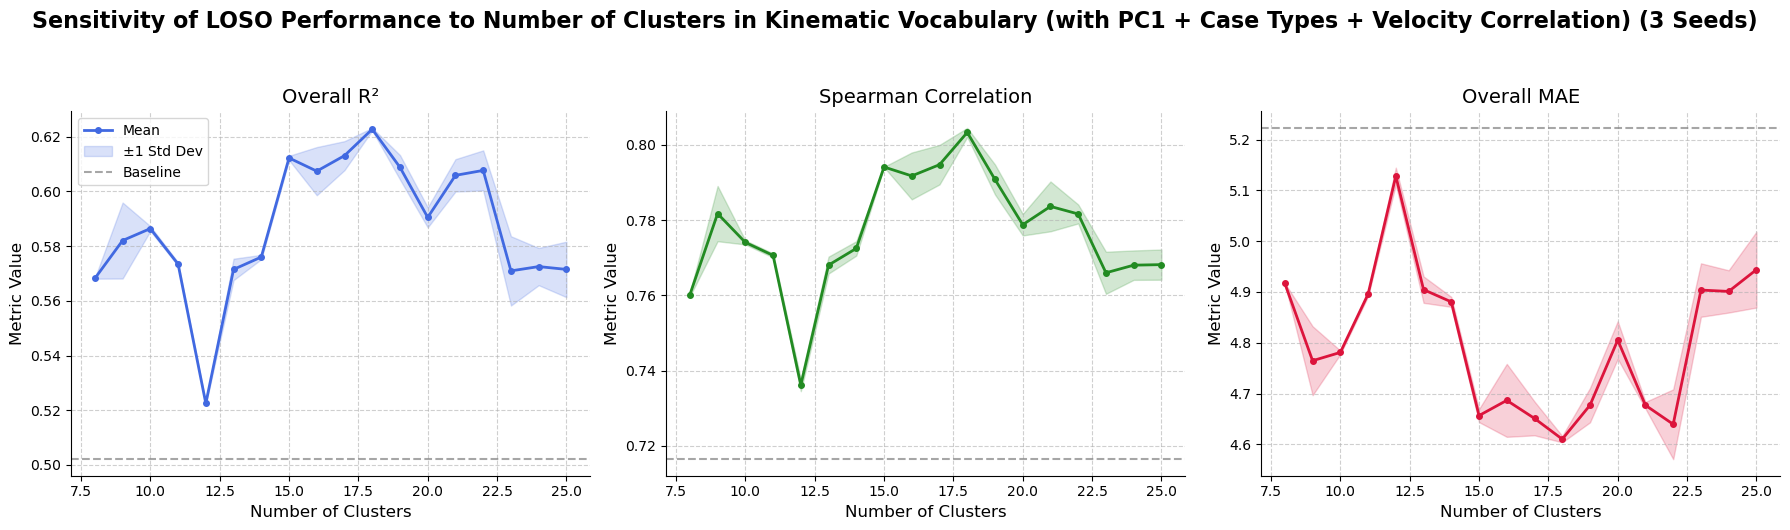

In [80]:
plot_sensitivity_results(cluster_range, results, title="Sensitivity of LOSO Performance to Number of Clusters in Kinematic Vocabulary (with PC1 + Case Types + Velocity Correlation)")

### Evaluate with K-means fitted inside of LOSO folds for K=18 with Velocity Correlation

**Thesis Result**

In [20]:
# with K = 18 !THESIS RESULT!
seed = 42
print('seed:', seed)
vocab = KinematicVocabulary(n_clusters=18, random_state=seed, model_type='kmeans', n_init=20,
                            feature_cols=['path_ratio', 'spatial_spread', 'palm_area_cv', 'sparc'],
                            log_feats=['path_ratio', 'spatial_spread', 'palm_area_cv', 'sparc'],
                            power_feats=None)


res = evaluator.evaluate_vocabulary(
    df_pc1_features,
    df_window,
    vocab,
    model=LassoCV(alphas=np.logspace(-1, 0.5, 30)),
    primary_features=pc1_features,
    bow_features=['SurgeMe_' + str(i) for i in range(18)],
    extra_features=['Case_1', 'Case_2', 'Case_3', 'Velocity corr.'],
    leakage_free=True,
    use_baseline=True,
)

summary = res['summary']
print_performance(summary, f"{n_cluster} Clusters - Results")

all_fold_centroids = res["fold_centroids"]

seed: 42


Vocabulary LOSO: 100%|██████████| 28/28 [01:50<00:00,  3.96s/it]

=== 25 Clusters - Results ===
MAE: 4.6548 ± 3.3804
Spearman R: 0.7958 and R²: 0.6180



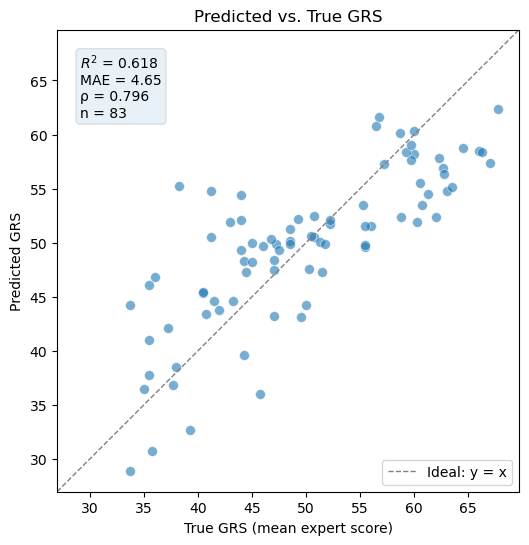

In [21]:
_, _ = plot_predicted_vs_true(res['predictions'], 
                       show_group_labels=False, 
                       add_fit_line=False)